# 02d — Prompt-Variant Model Analysis (Phase 2)

The Phase-2 counterpart to `01g`. Same lens (feature reliance + error analysis), but
the axis here is the **prompt design**, with the model held fixed at GPT-5.4. The
question shifts from *which model?* to *does the way we prompt change what the model
relies on and where it fails?*

Structure:
1. **Brief prompt-variant comparison** — the variants on headline metrics.
2. **Feature reliance across prompts** — does prompt design shift which features the
   model's decisions track?
3. **Error analysis across prompts** — which variant best reduces false rejections /
   missed defaults, and what that costs.

- Reads `02b_predictions.csv` (already on disk) — **no API calls.**
- Uses the **Phase-1 comparison block** of `02b` (6 variants × the 100
  `tuning_sample` loans). Consistency/robustness phases are excluded here.
- **`test_batch` is never touched.**


In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from llm_utils import load_llm_sample, LLM_FEATURES

RESULTS_LLM = '../../../data/results/llm'

metrics = pd.read_csv(f'{RESULTS_LLM}/02b_phase1_metrics.csv')
preds   = pd.read_csv(f'{RESULTS_LLM}/02b_predictions.csv')
preds   = preds[preds['phase'] == 1].copy()        # comparison block on tuning_sample
sample  = load_llm_sample()
y_true  = sample['loan_status'].values
VARIANTS = list(metrics['variant'])
print('Prompt variants (Phase 1):', VARIANTS)
print(f'Sample = {len(sample)} loans | default rate = {1-y_true.mean():.2f}')


Prompt variants (Phase 1): ['conservative', 'chain_of_thought', 'few_shot', 'top_features_only', 'structured_4factor', 'risk_signal_guide']
Sample = 100 loans | default rate = 0.15


## Part 1 — Brief Prompt-Variant Comparison

How the 7 prompt designs rank on the headline metrics (GPT-5.4 fixed). The risk class
is `Charged Off`. (Cost + reasoning fingerprints per variant live in `02c`.)

,variant,description,accuracy,f1_charged_off,recall_charged_off,auc
1,chain_of_thought,Explicit step-by-step reasoning through risk f...,0.83,0.370,0.333,0.645
2,few_shot,4 labeled training examples prepended before e...,0.82,0.357,0.333,0.637
4,structured_4factor,Explicit 4-factor evaluation framework in the ...,0.78,0.353,0.400,0.613
5,risk_signal_guide,Expert prompt: 7 ranked risk signals with empi...,0.75,0.324,0.400,0.635
3,top_features_only,Only the 8 most important features by XGBoost ...,0.68,0.304,0.467,0.632
0,conservative,Risk-averse underwriter; bias toward flagging ...,0.54,0.303,0.667,0.620


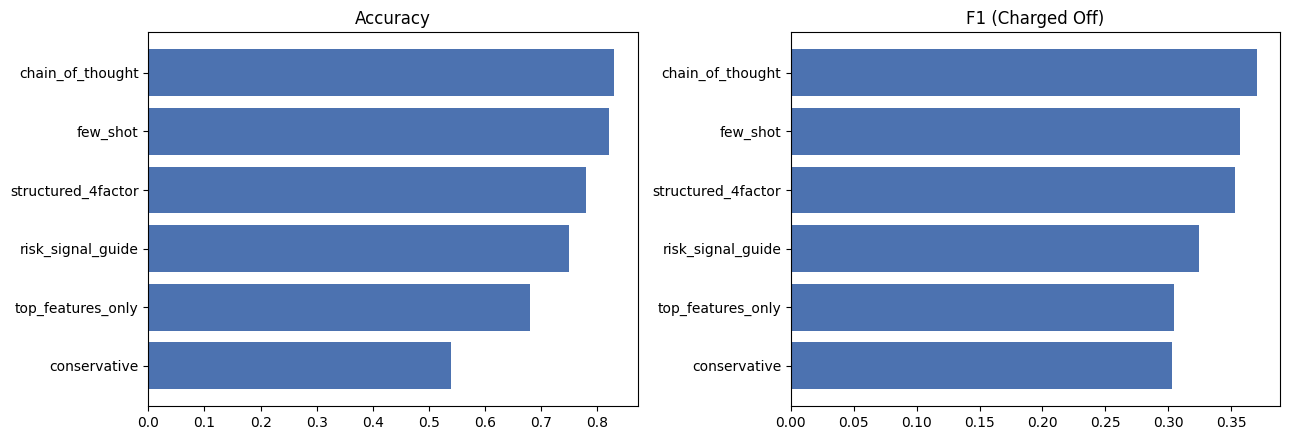

In [2]:
view = metrics[['variant', 'description', 'accuracy', 'f1_charged_off',
                'recall_charged_off', 'auc']].sort_values('f1_charged_off', ascending=False).round(3)
display(view)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, ttl in [(axes[0], 'accuracy', 'Accuracy'), (axes[1], 'f1_charged_off', 'F1 (Charged Off)')]:
    d = metrics.sort_values(col)
    ax.barh(d['variant'], d[col], color='#4C72B0'); ax.set_title(ttl)
plt.tight_layout(); plt.show()


## Part 2 — Feature Reliance Across Prompts

For each prompt variant we fit a **global surrogate** (a transparent model trained to
reproduce that variant's predictions from the loan features) and read its feature
importances — the same method as `01g`, repeated per prompt. The heatmap shows whether
prompt design **moves the model's reliance** onto different signals (e.g. does
chain-of-thought or top-features broaden it?). Per-variant surrogate fidelity is
reported so weakly-mimicked variants can be discounted.

In [3]:
ORDINAL = {
    'term': {' 36 months': 36, ' 60 months': 60},
    'emp_length': {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
                   '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
                   '10+ years': 10},
    'grade': {g: i for i, g in enumerate('ABCDEFG', start=1)},
}
NOMINAL = ['home_ownership', 'verification_status', 'purpose',
           'initial_list_status', 'application_type']

def encode_for_surrogate(df):
    df = df.copy()
    if 'mths_since_last_delinq' in df:
        df['has_past_delinq'] = df['mths_since_last_delinq'].notna().astype(int)
        df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(999)
    if 'issue_d' in df and 'earliest_cr_line' in df:
        df['credit_history_years'] = (pd.to_datetime(df['issue_d']) -
                                      pd.to_datetime(df['earliest_cr_line'])).dt.days / 365.25
    cols = {}
    for f in LLM_FEATURES:
        if f not in df: continue
        if f in ORDINAL:
            cols[f] = df[f].map(ORDINAL[f]) if not pd.api.types.is_numeric_dtype(df[f]) else df[f]
        elif f == 'sub_grade':
            cols[f] = df[f].astype('category').cat.codes
        elif f in NOMINAL:
            for col, s in pd.get_dummies(df[f], prefix=f).items():
                cols[col] = s
        else:
            cols[f] = pd.to_numeric(df[f], errors='coerce')
    return pd.DataFrame(cols).fillna(0.0)

def source_of(col):
    if col in LLM_FEATURES: return col
    cands = [f for f in LLM_FEATURES if col.startswith(f + '_')]
    return max(cands, key=len) if cands else col

X_surr = encode_for_surrogate(sample)
print('Surrogate matrix:', X_surr.shape)


Surrogate matrix: (100, 41)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_val_score

reliance, fidelity = {}, {}
for v in VARIANTS:
    block = preds[preds['variant'] == v].sort_values('loan_index')
    X = X_surr.iloc[block['loan_index'].values].reset_index(drop=True)
    yhat = block['prediction'].values
    m = ~pd.isna(yhat)
    X, yhat = X[m].reset_index(drop=True), yhat[m].astype(int)
    if len(np.unique(yhat)) < 2:
        fidelity[v] = np.nan; reliance[v] = pd.Series(0.0, index=LLM_FEATURES); continue
    fidelity[v] = cross_val_score(RandomForestClassifier(n_estimators=400, random_state=42),
                                  X, yhat, cv=5, scoring='accuracy').mean()
    surr = RandomForestClassifier(n_estimators=400, random_state=42).fit(X, yhat)
    pi = permutation_importance(surr, X, yhat, scoring='accuracy', n_repeats=20, random_state=42)
    agg = {}
    for col, w in zip(X.columns, pi.importances_mean):
        agg[source_of(col)] = agg.get(source_of(col), 0.0) + float(w)
    reliance[v] = pd.Series(agg)

fid_df = pd.Series(fidelity).rename('surrogate_fidelity').to_frame().round(2)
print('Per-variant surrogate fidelity (5-fold acc reproducing the prompt\'s labels):')
display(fid_df)


Per-variant surrogate fidelity (5-fold acc reproducing the prompt's labels):


,surrogate_fidelity
conservative,0.78
chain_of_thought,0.89
few_shot,0.88
top_features_only,0.89
structured_4factor,0.87
risk_signal_guide,0.86


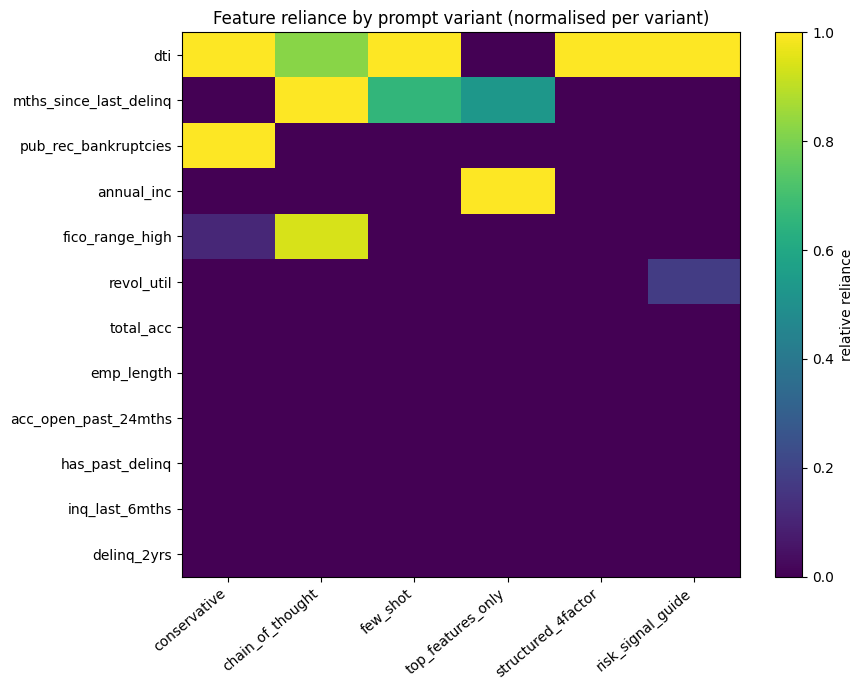

Top feature for each variant:


,top_feature
conservative,dti
chain_of_thought,mths_since_last_delinq
few_shot,dti
top_features_only,annual_inc
structured_4factor,dti
risk_signal_guide,dti


In [5]:
# Reliance heatmap: variants x top source features (normalised per variant).
R = pd.DataFrame(reliance).fillna(0.0)              # features x variants
R = R.clip(lower=0)
top_feats = R.max(axis=1).sort_values(ascending=False).head(12).index
H = R.loc[top_feats]
Hn = H / H.max(axis=0).replace(0, 1)                # normalise each variant column to its own max

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(Hn.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(Hn.columns))); ax.set_xticklabels(Hn.columns, rotation=40, ha='right')
ax.set_yticks(range(len(Hn.index)));   ax.set_yticklabels(Hn.index)
ax.set_title('Feature reliance by prompt variant (normalised per variant)')
fig.colorbar(im, ax=ax, label='relative reliance'); plt.tight_layout(); plt.show()

print('Top feature for each variant:')
display(H.idxmax().rename('top_feature').to_frame())


## Part 3 — Error Analysis Across Prompts

Per-variant error breakdown and its portfolio cost. The live Phase-2 question is
whether any prompt cuts **false rejections** (the dominant cost in the `01f`/`02c`
ledger) without giving back missed defaults. Cost constants match the ledger
(LGD €5,000 / missed default; €2,000 / false rejection).

,variant,caught_default_TP,missed_default_FN,false_reject_FP,credit_loss_EUR,lost_profit_EUR,total_error_cost_EUR
1,chain_of_thought,5,10,7,50000,14000,64000
2,few_shot,5,10,8,50000,16000,66000
4,structured_4factor,6,9,13,45000,26000,71000
5,risk_signal_guide,6,9,16,45000,32000,77000
3,top_features_only,7,8,24,40000,48000,88000
0,conservative,10,5,41,25000,82000,107000


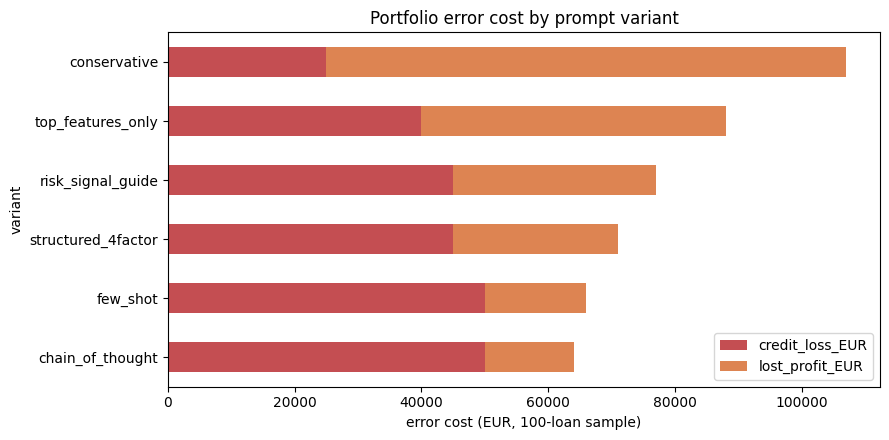

Lower total cost = better trade-off. Compare against XGBoost EUR 94,000 and GPT-5.4 no_desc EUR 65,000 (notebook 01g) on the same 100 loans.


In [6]:
LGD_COST, FP_COST = 5000, 2000
rows = []
for v in VARIANTS:
    block = preds[preds['variant'] == v].sort_values('loan_index')
    yt = block['actual'].values
    yp = block['prediction'].values
    m = ~pd.isna(yp); yt, yp = yt[m].astype(int), yp[m].astype(int)
    fn = int(((yt == 0) & (yp == 1)).sum())   # missed default
    fp = int(((yt == 1) & (yp == 0)).sum())   # false rejection: actually paid, predicted charge-off
    tp = int(((yt == 0) & (yp == 0)).sum())
    rows.append({'variant': v, 'caught_default_TP': tp, 'missed_default_FN': fn,
                 'false_reject_FP': fp,
                 'credit_loss_EUR': fn * LGD_COST, 'lost_profit_EUR': fp * FP_COST,
                 'total_error_cost_EUR': fn * LGD_COST + fp * FP_COST})
cost = pd.DataFrame(rows).sort_values('total_error_cost_EUR')
display(cost)

fig, ax = plt.subplots(figsize=(9, 4.5))
c = cost.set_index('variant')[['credit_loss_EUR', 'lost_profit_EUR']]
c.plot.barh(stacked=True, ax=ax, color=['#C44E52', '#DD8452'])
ax.set_xlabel('error cost (EUR, 100-loan sample)')
ax.set_title('Portfolio error cost by prompt variant'); plt.tight_layout(); plt.show()
print('Lower total cost = better trade-off. Compare against XGBoost EUR 94,000 and '
      'GPT-5.4 no_desc EUR 65,000 (notebook 01g) on the same 100 loans.')


## Takeaways

- Feature reliance and error cost are now profiled per prompt variant, mirroring the
  per-model analysis in `01g`.
- The heatmap shows whether prompt design **redirects** the model's reliance; the cost
  table shows which design best controls false rejections — the Phase-2 lever for
  pushing GPT-5.4 no_desc higher.
- Read with `02c` (cost ledger + reasoning fingerprints) for the full Phase-2 picture.